In [15]:
import xarray as xr
import pandas as pd
import datetime as dt
import tqdm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scores.continuous as scc_cont
import sys

sys.path.append("../src/helpers")
from analysis_helpers import combine_state_features

# Load predictions
predictions = xr.open_dataset("../evals/bare-minimum_unroll30.zarr", engine="zarr", chunks='auto')

# Load ground truth
ground_truth = xr.open_dataset("../data/experiment/data/datastore.interior.domain03.zarr", engine="zarr", chunks='auto')

In [16]:
combined_predictions = combine_state_features(predictions)
combined_ground_truth = combine_state_features(ground_truth)

In [17]:
frequency = "1h"  # Frequency of forecasts
length_of_forecast = 10  # Length of forecast in time steps

In [18]:
combined_predictions

<xarray.Dataset> Size: 21GB
Dimensions:                    (elapsed_forecast_duration: 30,
                                grid_index: 524288, start_time: 335)
Coordinates:
  * elapsed_forecast_duration  (elapsed_forecast_duration) timedelta64[ns] 240B ...
  * grid_index                 (grid_index) int64 4MB 11255161 ... 3934314
  * start_time                 (start_time) datetime64[ns] 3kB 2020-02-12T00:...
    state_feature              <U13 52B 't_2m'
    time                       (elapsed_forecast_duration) datetime64[ns] 240B dask.array<chunksize=(30,), meta=np.ndarray>
Data variables:
    t_2m                       (start_time, elapsed_forecast_duration, grid_index) float32 21GB dask.array<chunksize=(8, 8, 524288), meta=np.ndarray>

In [19]:
pcollection = []
rcollection = []
for forecast, init_time in enumerate(tqdm.tqdm(pd.date_range(
        start=predictions.start_time.min().values,
        end=predictions.start_time.max().values,
        freq=frequency,
    ))):
    # Extract the forecast time slice
    try:
        ground_truth = combined_ground_truth.sel(time=slice(init_time+dt.timedelta(minutes=10), init_time + dt.timedelta(minutes=10*length_of_forecast)))
        predictions = combined_predictions.sel(start_time=init_time).isel(elapsed_forecast_duration=slice(0, length_of_forecast))
    except KeyError:
        print(f"KeyError for init_time: {init_time}, skipping...")
        continue
    assert len(predictions.time) == length_of_forecast, f"Forecast length mismatch: {len(predictions.time)} != {length_of_forecast}"
    assert len(ground_truth.time) == length_of_forecast, f"Ground truth length mismatch: {len(ground_truth.time)} != {length_of_forecast}"

    preds = predictions.rename({'elapsed_forecast_duration': 'leadtime',}).expand_dims('forecast').drop_vars(['time', 'start_time', 'state_feature'])
    reference = ground_truth.rename({'time': 'leadtime',}).expand_dims('forecast').drop_vars(['state_feature', 'state_feature_long_name', 'state_feature_units', 'state_feature_source_dataset'])
    reference = reference.assign_coords({'leadtime': pd.date_range(start=init_time+dt.timedelta(minutes=10), periods=length_of_forecast, freq='10min') - init_time})


    pcollection.append(preds)
    rcollection.append(reference)
p = xr.concat( pcollection, dim='forecast')
r = xr.concat( rcollection, dim='forecast')


100%|██████████| 56/56 [00:00<00:00, 66.78it/s]


In [7]:
p

<xarray.Dataset> Size: 906MB
Dimensions:     (forecast: 43, leadtime: 10, grid_index: 524288)
Coordinates:
  * leadtime    (leadtime) timedelta64[ns] 80B 00:10:00 00:20:00 ... 01:40:00
  * grid_index  (grid_index) int64 4MB 11255161 11255162 ... 3934313 3934314
Dimensions without coordinates: forecast
Data variables:
    t_2m        (forecast, leadtime, grid_index) float32 902MB dask.array<chunksize=(1, 8, 524288), meta=np.ndarray>

In [8]:
rmse = scc_cont.rmse(p, r, preserve_dims=['leadtime', 'forecast'])

In [9]:
print(rmse)

<xarray.Dataset> Size: 2kB
Dimensions:   (leadtime: 10, forecast: 43)
Coordinates:
  * leadtime  (leadtime) timedelta64[ns] 80B 00:10:00 00:20:00 ... 01:40:00
Dimensions without coordinates: forecast
Data variables:
    t_2m      (forecast, leadtime) float32 2kB dask.array<chunksize=(1, 2), meta=np.ndarray>


In [10]:
rmse_ = rmse.assign_coords(leadtime=rmse.leadtime.dt.total_seconds() / (60 * 60))[['t_2m']] #, 'u_10m', 'v_10m']]

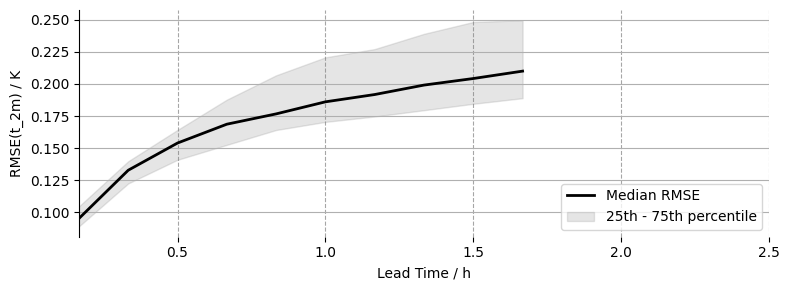

In [11]:
def plot_rmse_timeseries(ax, rmse_ds, percentiles=[25, 75]):
    """
    Plot RMSE time series with median and percentiles using Seaborn.

    Parameters:
    ax (matplotlib.axes.Axes): The subplot axis to plot on.
    rmse_ds (xarray.DataArray): The dataset containing RMSE values.
    percentiles (list): List of percentiles to plot.
    """
    # Calculate median and percentiles
    rmse_median = rmse_ds.quantile(0.5, dim='forecast')
    rmse_percentiles = {p: rmse_ds.quantile(p / 100, dim='forecast') for p in percentiles}

    # Prepare data for Seaborn
    leadtime = rmse_median.leadtime.values
    lower_percentiles = [rmse_percentiles[p].values for p in percentiles]
    upper_percentiles = [rmse_percentiles[100 - p].values for p in percentiles]

    # Plotting
    ax.plot(leadtime, rmse_median.values, color='black', label='Median RMSE', linewidth=2)
    ax.fill_between(leadtime, rmse_percentiles[min(percentiles)], rmse_percentiles[max(percentiles)], color='grey', alpha=0.2, label=f'{min(percentiles)}th - {max(percentiles)}th percentile')

    ax.set_xlabel('Lead Time / h')
    ax.set_ylabel(f'RMSE ({rmse_ds.name})')
    ax.legend(loc='lower right')
    ax.grid()

units = {
    't_2m': 'K',
    'u_10m': 'm/s',
    'v_10m': 'm/s'
}

# Create a single figure with subplots
fig, axes = plt.subplots(len(rmse_.data_vars), 1, figsize=(8, 3 * len(rmse_.data_vars)))
if len(rmse_.data_vars) == 1:
    axes = [axes]  # Ensure axes is iterable for a single subplot

for i, var in enumerate(rmse_.data_vars):
    da = rmse_[var]
    plot_rmse_timeseries(axes[i], da)

    if i != len(rmse_.data_vars) - 1:
        axes[i].set_xticklabels([])  # Remove x-tick labels for all but the last subplot
        axes[i].set_xlabel(None)
        axes[i].legend().remove()  # Remove legend for all but the last subplot
    else:
        axes[i].set_xlabel('Lead Time / h')  # Set x-label for the last subplot
    axes[i].set_xlim(1/6, 2.5)
    axes[i].set_ylabel(f'RMSE({var}) / {units[var]}')
    axes[i].grid(axis='x', which='major', linestyle='--', color='grey', alpha=0.7)
sns.despine(bottom=True)
plt.tight_layout()
plt.show()


In [22]:
## Quantile score
quantile_score = scc_cont.quantile_score(p, r, preserve_dims=['leadtime', 'forecast'], alpha=0.75)
quantile_score = quantile_score.assign_coords(leadtime=quantile_score.leadtime.dt.total_seconds() / (60 * 60))[['t_2m',]] # 'u_10m', 'v_10m']]

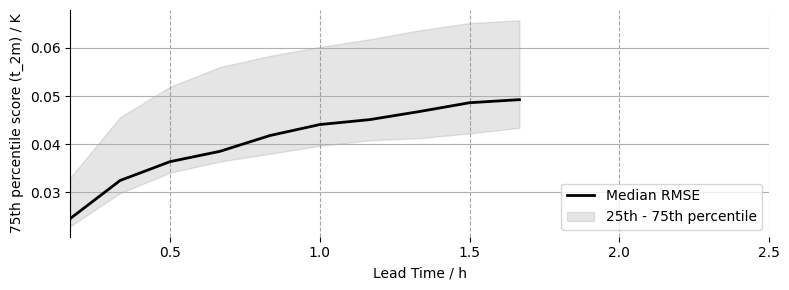

In [23]:
units = {
    't_2m': 'K',
    'u_10m': 'm/s',
    'v_10m': 'm/s'
}

score = quantile_score

# Create a single figure with subplots
fig, axes = plt.subplots(len(score.data_vars), 1, figsize=(8, 3 * len(score.data_vars)))
if len(score.data_vars) == 1:
    axes = [axes]  # Ensure axes is iterable for a single subplot

for i, var in enumerate(score.data_vars):
    da = score[var]
    plot_rmse_timeseries(axes[i], da)

    if i != len(score.data_vars) - 1:
        axes[i].set_xticklabels([])  # Remove x-tick labels for all but the last subplot
        axes[i].set_xlabel(None)
        axes[i].legend().remove()  # Remove legend for all but the last subplot
    else:
        axes[i].set_xlabel('Lead Time / h')  # Set x-label for the last subplot
    axes[i].set_xlim(1/6, 2.5)
    axes[i].set_ylabel(f'75th percentile score ({var}) / {units[var]}')
    axes[i].grid(axis='x', which='major', linestyle='--', color='grey', alpha=0.7)
sns.despine(bottom=True)
plt.tight_layout()
plt.show()

In [16]:
## Histogram

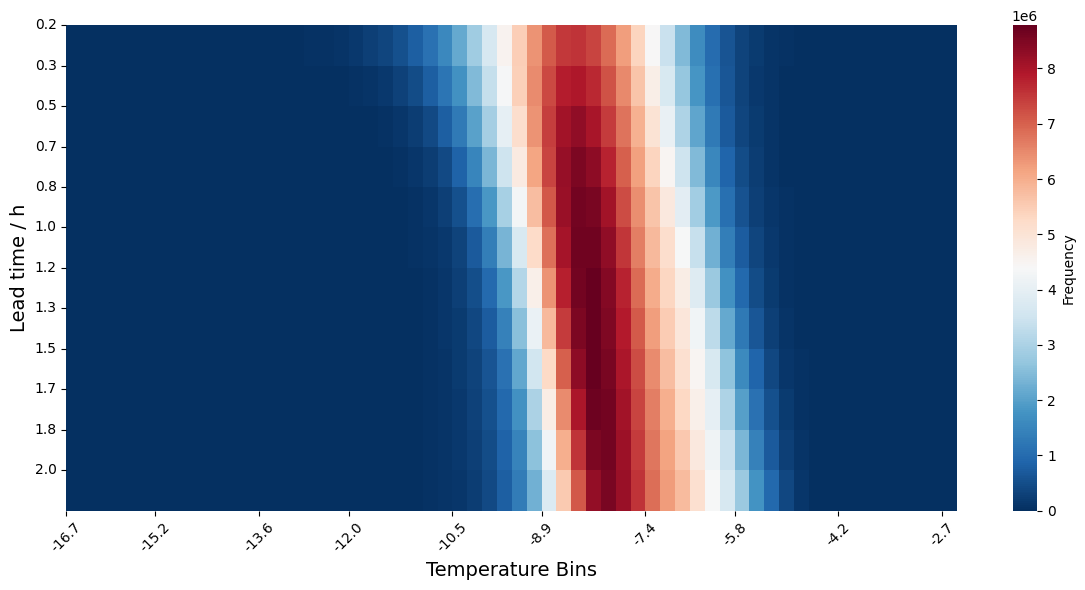

In [20]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_hovmoller_temperature_histogram(ds, temp_var='t_2m', num_bins=40):
    """
    Plot a Hovmöller diagram of temperature histograms.

    Parameters:
    ds (xarray.Dataset): The dataset containing temperature data.
    temp_var (str): The name of the temperature variable in the dataset.
    num_bins (int): The number of temperature bins for the histogram.
    """
    # Get the temperature data
    temperature_data = ds[temp_var].values  # Assuming shape (time, space)

    # Define temperature bins
    min_temp = np.nanmin(temperature_data)
    max_temp = np.nanmax(temperature_data)
    bins = np.linspace(float(min_temp), float(max_temp), num_bins + 1)

    # Initialize an array to hold histogram frequencies
    histogram_frequencies = np.zeros((len(ds.leadtime), num_bins))

    # Calculate histogram for each time step
    for i in range(len(ds.leadtime)):
        histogram_frequencies[i, :], _ = np.histogram(temperature_data[:, i, :], bins=bins)

    # Create a Hovmöller diagram
    plt.figure(figsize=(12, 6))
    sns.heatmap(histogram_frequencies, cmap='RdBu_r', cbar=True,
                yticklabels=ds.leadtime.values, xticklabels=bins[:-1], 
                cbar_kws={'label': 'Frequency'})

    # Set labels and title
    # plt.title('Hovmöller Diagram of Temperature Histograms', fontsize=16)
    plt.ylabel('Lead time / h', fontsize=14)
    plt.xlabel('Temperature Bins', fontsize=14)
    plt.xticks(ticks=np.linspace(0, len(bins) - 2, 10, dtype=int), 
               labels=np.round(np.linspace(min_temp, max_temp, 10), 1), 
               rotation=45)
    plt.yticks(ticks=np.arange(len(ds.leadtime)),
               labels=np.round(ds.leadtime.values, 1), 
               rotation=0)
    plt.tight_layout()
    plt.show()

# Example usage:
# ds = xr.open_dataset('your_temperature_dataset.nc')  # Load your dataset
p_ = p.assign_coords(leadtime=p.leadtime.dt.total_seconds() / (60 * 60))[['t_2m', 'u_10m', 'v_10m']]
plot_hovmoller_temperature_histogram(p_, temp_var='u_10m', num_bins=60)


In [29]:
std = p_.std(dim=['forecast', 'grid_index'])

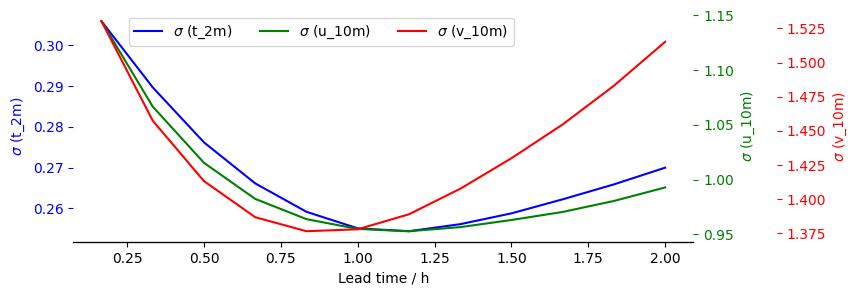

In [32]:
fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot t_2m on the first y-axis
ax1.plot(std.leadtime, std['t_2m'], label=r'$\sigma$ (t_2m)', color='blue')
ax1.set_ylabel(r'$\sigma$ (t_2m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue', colors='blue')

# Create a second y-axis for u_10m
ax2 = ax1.twinx()
ax2.plot(std.leadtime, std['u_10m'], label=r'$\sigma$ (u_10m)', color='green')
ax2.set_ylabel(r'$\sigma$ (u_10m)', color='green')
ax2.tick_params(axis='y', labelcolor='green', colors='green')

# Create a third y-axis for v_10m
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
ax3.plot(std.leadtime,std['v_10m'], label=r'$\sigma$ (v_10m)', color='red')
ax3.set_ylabel(r'$\sigma$ (v_10m)', color='red')
ax3.tick_params(axis='y', labelcolor='red', colors='red')

# Set x-axis label
ax1.set_xlabel('Lead time / h')

# Add a legend
fig.legend(loc='upper center', bbox_to_anchor=(0.4, 1.), ncol=3, bbox_transform=ax3.transAxes)

sns.despine(left=True)

In [ ]:
std = r.std(dim=['forecast', 'grid_index'])

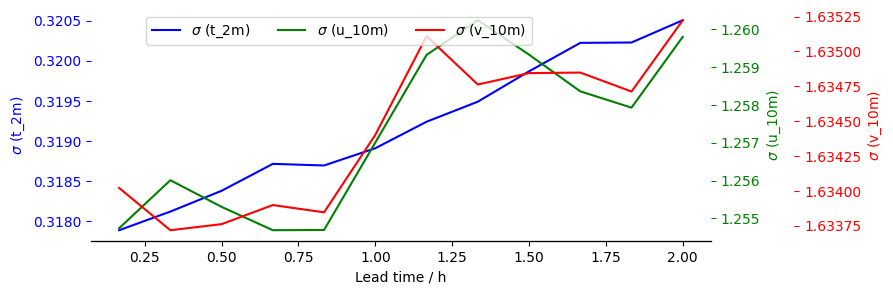

In [43]:
fig, ax1 = plt.subplots(figsize=(8, 3))

# Plot t_2m on the first y-axis
ax1.plot(std.leadtime.dt.total_seconds() / (60 * 60), std['t_2m'], label=r'$\sigma$ (t_2m)', color='blue')
ax1.set_ylabel(r'$\sigma$ (t_2m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue', colors='blue')

# Create a second y-axis for u_10m
ax2 = ax1.twinx()
ax2.plot(std.leadtime.dt.total_seconds() / (60 * 60), std['u_10m'], label=r'$\sigma$ (u_10m)', color='green')
ax2.set_ylabel(r'$\sigma$ (u_10m)', color='green')
ax2.tick_params(axis='y', labelcolor='green', colors='green')

# Create a third y-axis for v_10m
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
ax3.plot(std.leadtime.dt.total_seconds() / (60 * 60), std['v_10m'], label=r'$\sigma$ (v_10m)', color='red')
ax3.set_ylabel(r'$\sigma$ (v_10m)', color='red')
ax3.tick_params(axis='y', labelcolor='red', colors='red')

# Set x-axis label
ax1.set_xlabel('Lead time / h')

# Add a legend
fig.legend(loc='upper center', bbox_to_anchor=(0.4, 1.), ncol=3, bbox_transform=ax3.transAxes)

sns.despine(left=True)

## IQR

In [20]:
q25 = p.quantile(0.25, dim=['forecast', 'grid_index'])
q75 = p.quantile(0.75, dim=['forecast', 'grid_index'])

# Calculate IQR
iqr = q75 - q25

NameError: name 'ax3' is not defined

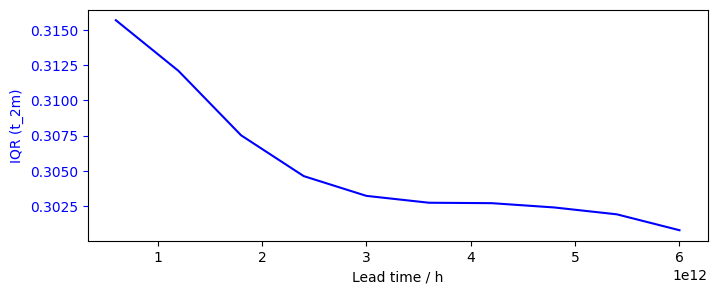

In [21]:
fig, ax1 = plt.subplots(figsize=(8, 3))
# Plot t_2m on the first y-axis
ax1.plot(iqr.leadtime, iqr['t_2m'], label=r'IQR (t_2m)', color='blue')
ax1.set_ylabel(r'IQR (t_2m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue', colors='blue')
# # Create a second y-axis for u_10m
# ax2 = ax1.twinx()
# ax2.plot(iqr.leadtime, iqr['u_10m'], label=r'IQR (u_10m)', color='green')
# ax2.set_ylabel(r'IQR (u_10m)', color='green')
# ax2.tick_params(axis='y', labelcolor='green', colors='green')
# # Create a third y-axis for v_10m
# ax3 = ax1.twinx()
# ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
# ax3.plot(iqr.leadtime, iqr['v_10m'], label=r'IQR (v_10m)', color='red')
# ax3.set_ylabel(r'IQR (v_10m)', color='red')
# ax3.tick_params(axis='y', labelcolor='red', colors='red')
# Set x-axis label
ax1.set_xlabel('Lead time / h')
# Add a legend
fig.legend(loc='upper center', bbox_to_anchor=(0.4, 1.), ncol=3, bbox_transform=ax3.transAxes)
sns.despine(left=True)

In [47]:
q25 = r.quantile(0.25, dim=['forecast', 'grid_index'])
q75 = r.quantile(0.75, dim=['forecast', 'grid_index'])

# Calculate IQR
iqr = q75 - q25

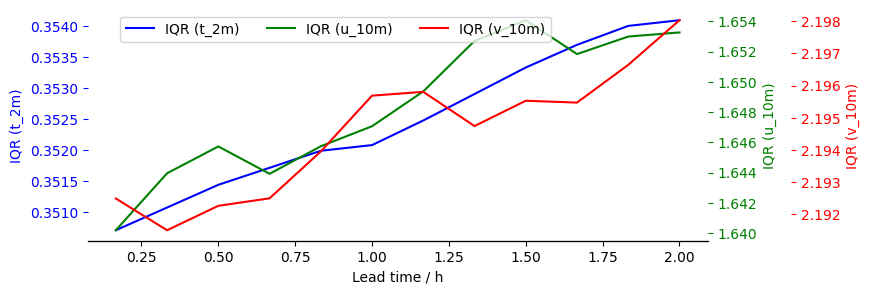

In [49]:
fig, ax1 = plt.subplots(figsize=(8, 3))
# Plot t_2m on the first y-axis
ax1.plot(iqr.leadtime.dt.total_seconds() / (60 * 60), iqr['t_2m'], label=r'IQR (t_2m)', color='blue')
ax1.set_ylabel(r'IQR (t_2m)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue', colors='blue')
# Create a second y-axis for u_10m
ax2 = ax1.twinx()
ax2.plot(iqr.leadtime.dt.total_seconds() / (60 * 60), iqr['u_10m'], label=r'IQR (u_10m)', color='green')
ax2.set_ylabel(r'IQR (u_10m)', color='green')
ax2.tick_params(axis='y', labelcolor='green', colors='green')
# Create a third y-axis for v_10m
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))  # Offset the third y-axis
ax3.plot(iqr.leadtime.dt.total_seconds() / (60 * 60), iqr['v_10m'], label=r'IQR (v_10m)', color='red')
ax3.set_ylabel(r'IQR (v_10m)', color='red')
ax3.tick_params(axis='y', labelcolor='red', colors='red')
# Set x-axis label
ax1.set_xlabel('Lead time / h')
# Add a legend
fig.legend(loc='upper center', bbox_to_anchor=(0.4, 1.), ncol=3, bbox_transform=ax3.transAxes)
sns.despine(left=True)